In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('WA_Fn-UseC_-Telco-Customer-Churn.csv')
df

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,6840-RESVB,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,...,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.5,No
7039,2234-XADUH,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.9,No
7040,4801-JZAZL,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,8361-LTMKD,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.6,Yes


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [4]:
#replacing blanks with 0 as tenure and no total charges are recorded
df["TotalCharges"] = df["TotalCharges"].replace(" ","0")
df["TotalCharges"] = df["TotalCharges"].astype("float")

In [5]:
df.isnull().sum().sum()

np.int64(0)

In [6]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
count,7043.000000,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692,2279.734304
std,0.368612,24.559481,30.090047,2266.794470
min,0.000000,0.000000,18.250000,0.000000
25%,0.000000,9.000000,35.500000,398.550000
50%,0.000000,29.000000,70.350000,1394.550000
75%,0.000000,55.000000,89.850000,3786.600000
max,1.000000,72.000000,118.750000,8684.800000


In [7]:
df.duplicated().sum()

np.int64(0)

In [8]:
#converted 0 and 1 values of senior citizen into yes/no to make it easier to understand
def conv(value):
  if value == 1:
    return "yes"
  else:
    return "no"

df['SeniorCitizen'] = df['SeniorCitizen'].apply(conv)

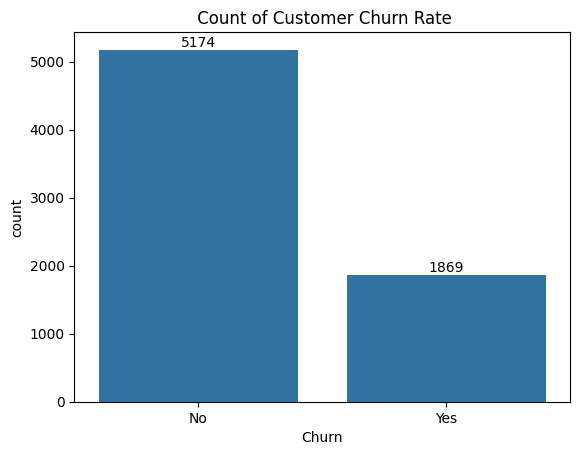

In [9]:
ax= sns.countplot(x = 'Churn', data = df)
ax.bar_label(ax.containers[0])
plt.title(" Count of Customer Churn Rate")
plt.show()

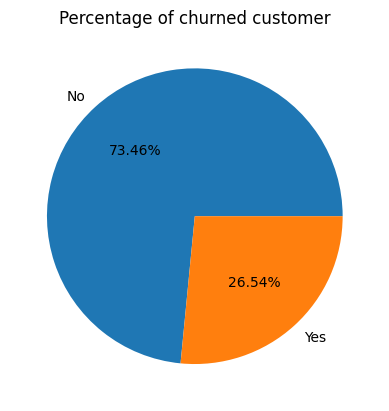

,Churn
Churn,
No,5174
Yes,1869


In [10]:
from numpy._core.defchararray import index
gb = df.groupby("Churn").agg({'Churn':'count'})
plt.pie(gb["Churn"], labels=gb.index, autopct='%1.2f%%')
plt.title("Percentage of churned customer")
plt.show()
gb

In [11]:
#from the given pie chart we can conclude that 26.54% of customers have been churned out
#now lets explore the reason behind it

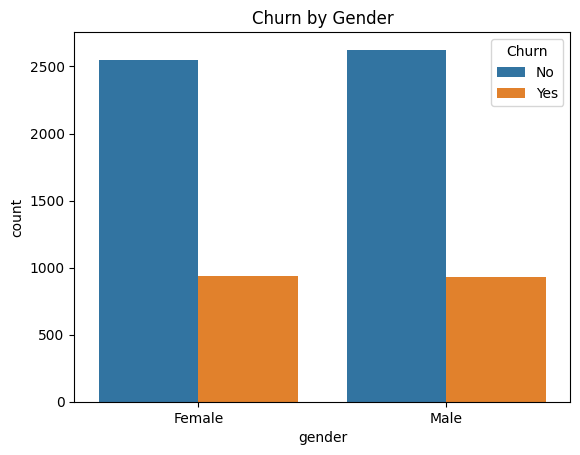

In [12]:
sns.countplot(x="gender", data= df, hue= "Churn")
plt.title("Churn by Gender")
plt.show()

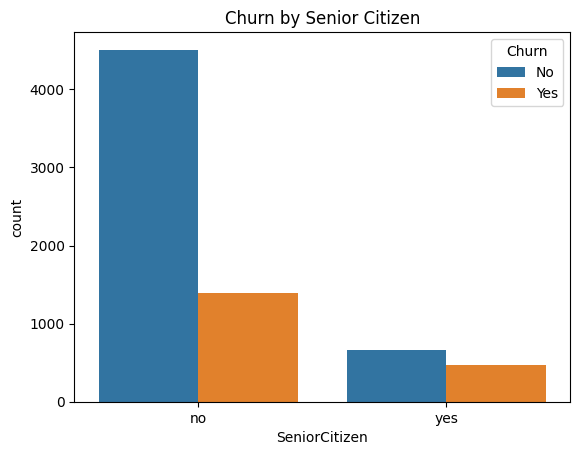

In [13]:
sns.countplot(x="SeniorCitizen", data= df, hue= "Churn")
plt.title("Churn by Senior Citizen")
plt.show()

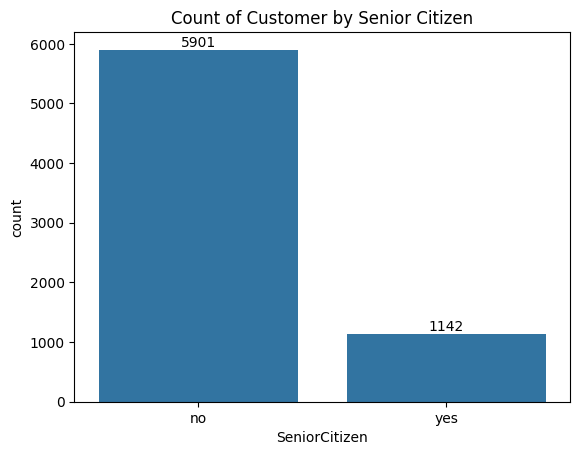

In [14]:

ax = sns.countplot(x="SeniorCitizen", data= df)
ax.bar_label(ax.containers[0])
plt.title("Count of Customer by Senior Citizen")
plt.show()

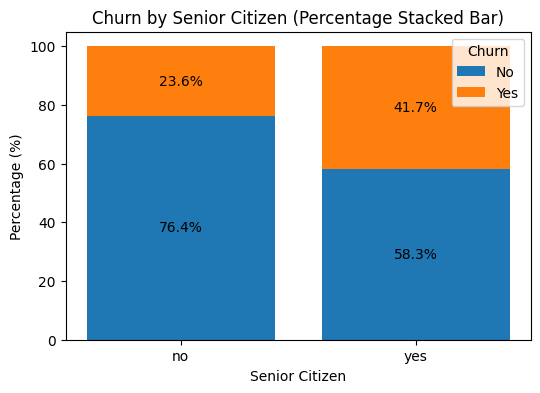

In [15]:
# Calculate counts
counts = df.groupby(["SeniorCitizen", "Churn"]).size().unstack(fill_value=0)

# Convert to % of row total
percentages = counts.div(counts.sum(axis=1), axis=0) * 100

# Plot
fig, ax = plt.subplots(figsize=(6, 4))

bottom_vals = [0, 0]  # to stack bars manually

for churn_value in percentages.columns:
    ax.bar(
        percentages.index.astype(str),
        percentages[churn_value],
        bottom=bottom_vals,
        label=str(churn_value)
    )
    bottom_vals = bottom_vals + percentages[churn_value].values

# Add % labels
for i, index in enumerate(percentages.index):
    cum = 0
    for churn_value in percentages.columns:
        val = percentages.loc[index, churn_value]
        if val > 0:
            ax.text(
                i,
                cum + val / 2,
                f"{val:.1f}%",
                ha="center",
                va="center",
                fontsize=10
            )
        cum += val

ax.set_title("Churn by Senior Citizen (Percentage Stacked Bar)")
ax.set_xlabel("Senior Citizen")
ax.set_ylabel("Percentage (%)")
ax.legend(title="Churn")

plt.show()

In [16]:
#comparative a greated percentage of people in Senior Citizen category have churned


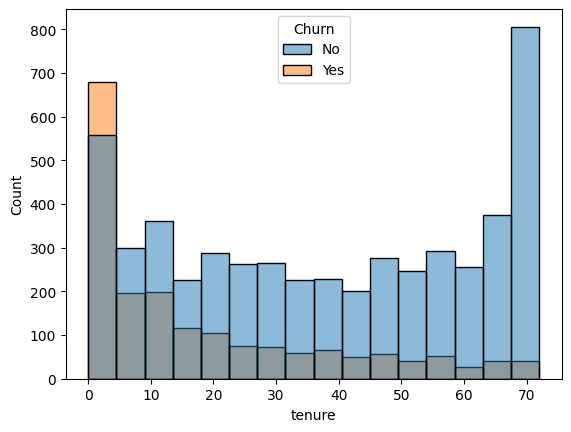

In [17]:
sns.histplot(x='tenure', data= df, hue="Churn")
plt.show()

In [18]:
#people who have used ouir services for a long time have stayed and people who have used for 1 or 2 months have chruned.

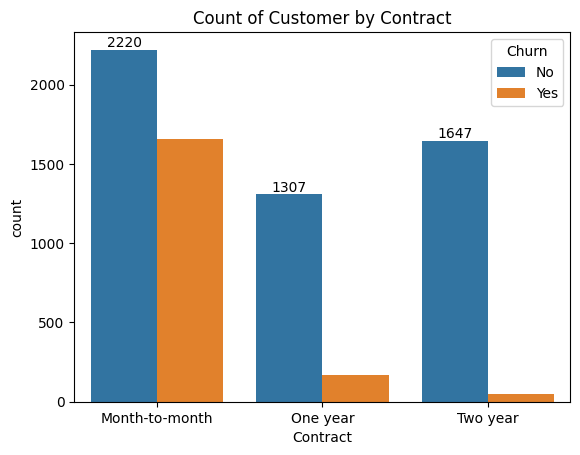

In [19]:
ax = sns.countplot(x="Contract", data= df, hue = "Churn")
ax.bar_label(ax.containers[0])
plt.title("Count of Customer by Contract")
plt.show()

In [20]:
#people who have month to month contract are likely to churn then from those who have 1 or 2 years of contract

In [21]:
df.columns.values

array(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
       'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract',
       'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges',
       'TotalCharges', 'Churn'], dtype=object)

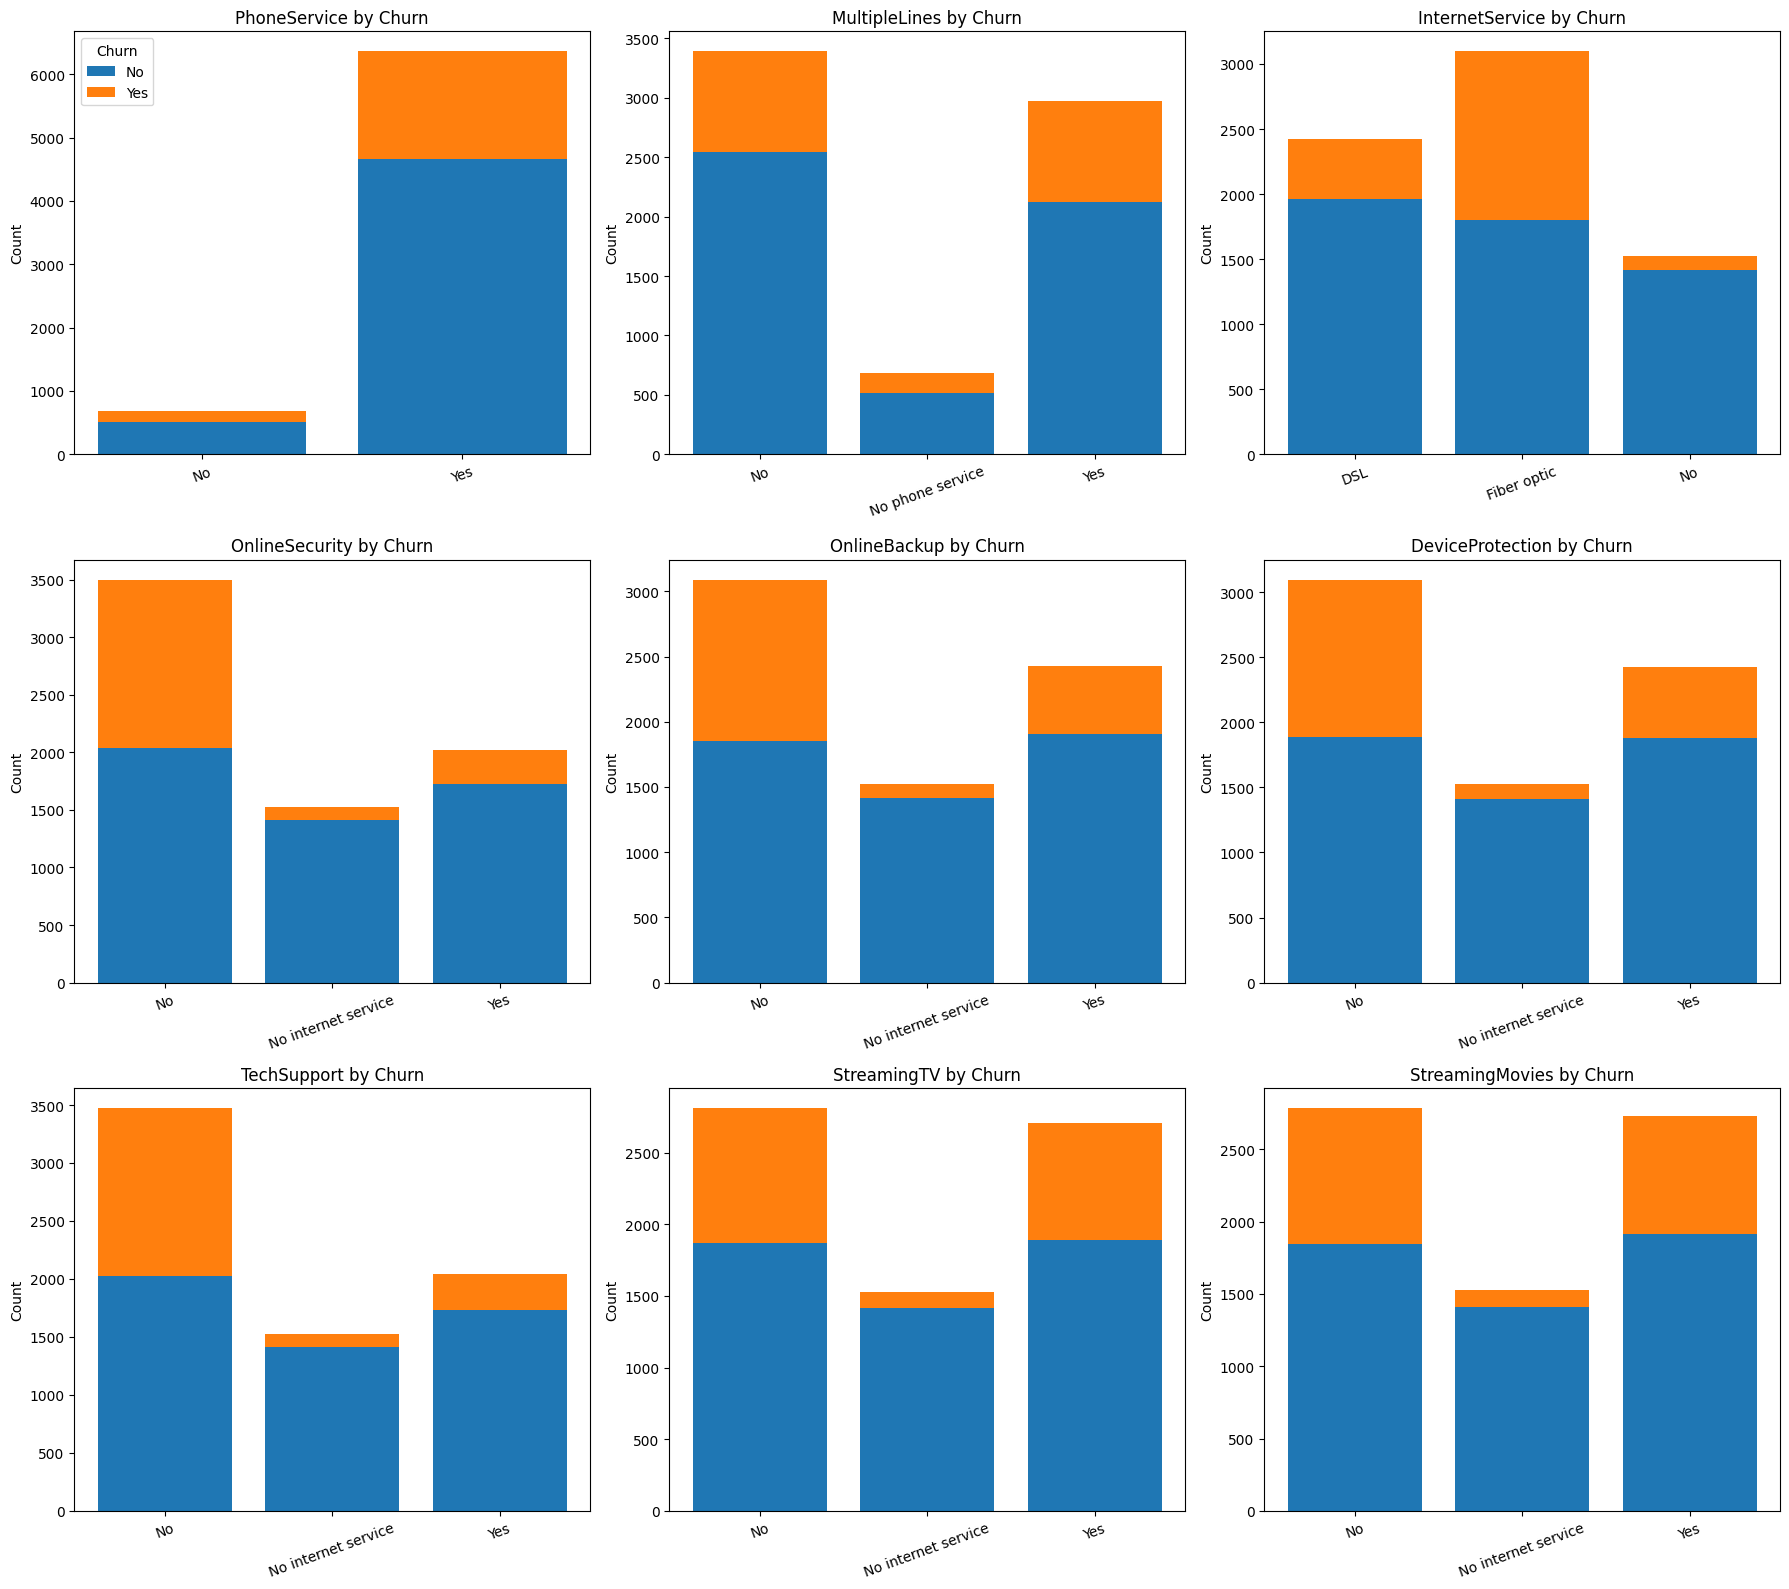

In [26]:
cols = [
    'PhoneService', 'MultipleLines', 'InternetService',
    'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
    'TechSupport', 'StreamingTV', 'StreamingMovies'
]

n_cols = 3
n_rows = (len(cols) + n_cols - 1) // n_cols

plt.figure(figsize=(18, 16))

for i, col in enumerate(cols, 1):
    plt.subplot(n_rows, n_cols, i)

    # Count each category by Churn
    counts = df.groupby([col, "Churn"]).size().unstack(fill_value=0)

    # Categories for x-axis
    x = range(len(counts.index))

    # Bottom for stacking
    bottom = [0] * len(counts.index)

    # Plot each Churn group
    for churn_value in counts.columns:
        plt.bar(
            x,
            counts[churn_value],
            bottom=bottom,
            label=str(churn_value)
        )
        # update bottom for next stack
        bottom = bottom + counts[churn_value].values

    plt.xticks(x, counts.index.astype(str), rotation=20)
    plt.title(f"{col} by Churn")
    plt.ylabel("Count")

    if i == 1:      # show legend only once
        plt.legend(title="Churn")

plt.tight_layout()
plt.show()

In [27]:
#The charts show how customer churn varies across different service categories such as InternetService, TechSupport, StreamingTV, and others. In most categories, customers with “No” service tend to have lower churn compared to those who actively use the service. Internet-related services show a clear pattern where customers lacking security, backup, or tech support display higher churn counts. Overall, churn appears more concentrated among users actively subscribed to additional services.

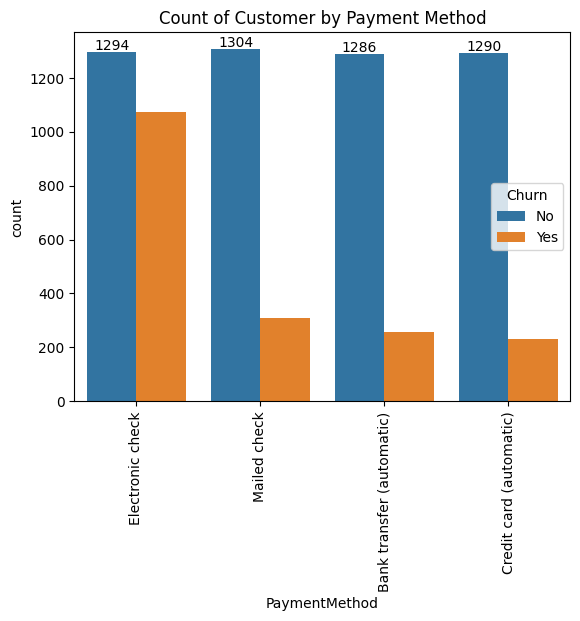

In [30]:
ax = sns.countplot(x="PaymentMethod", data= df, hue = "Churn")
ax.bar_label(ax.containers[0])
plt.title("Count of Customer by Payment Method")
plt.xticks(rotation= 90)
plt.show()

In [31]:
#customer is likely to churn when he is using electronic check as a payment method